   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose       

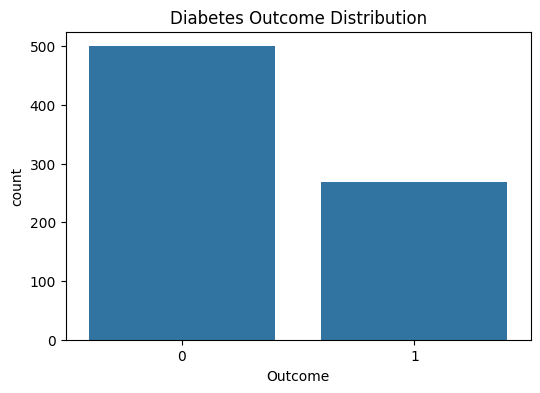

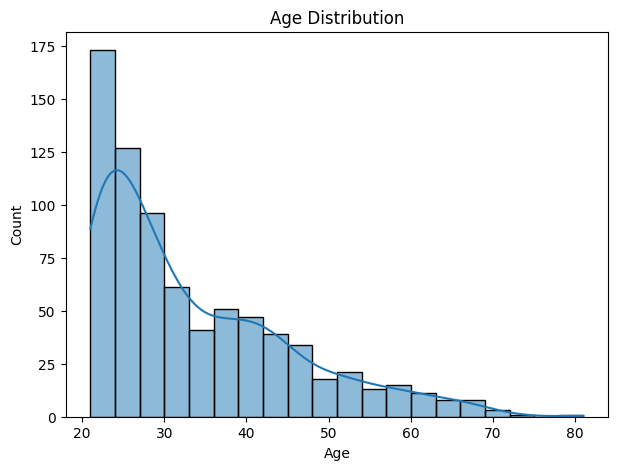

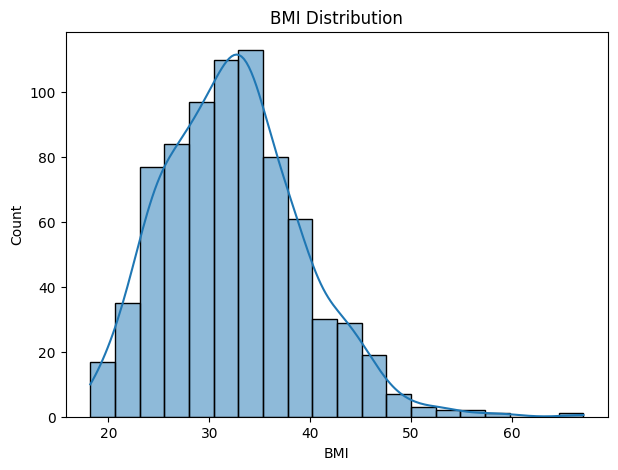

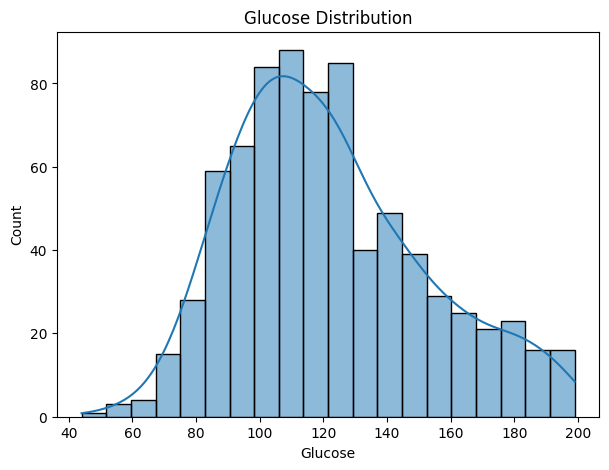

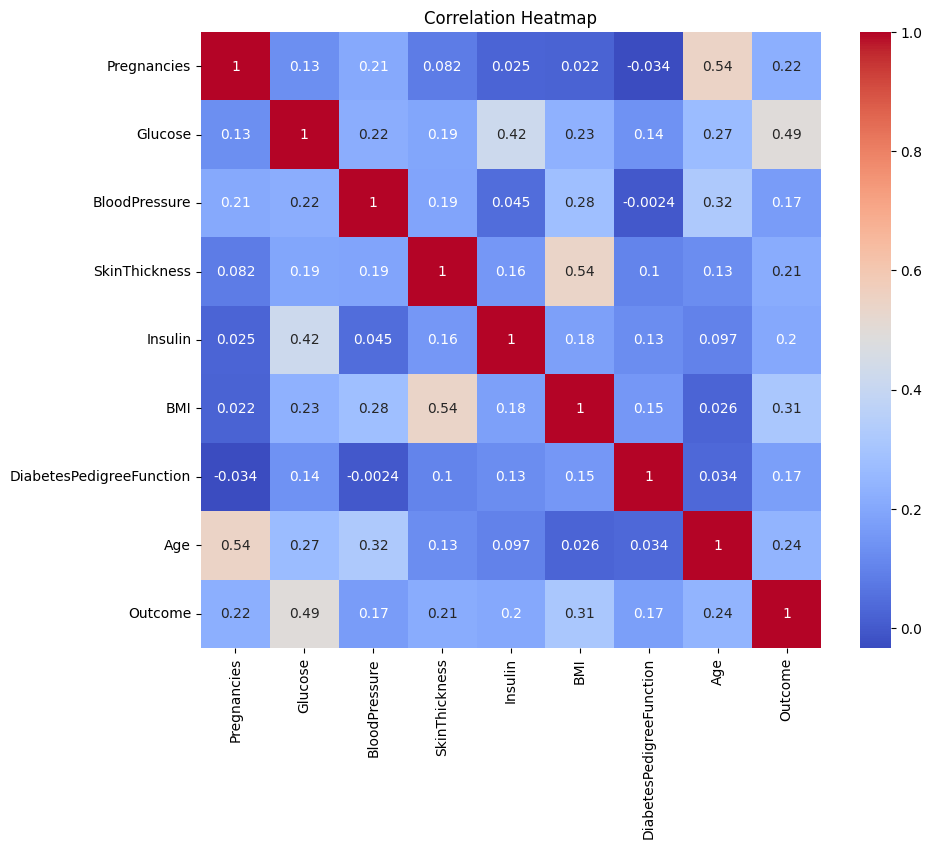

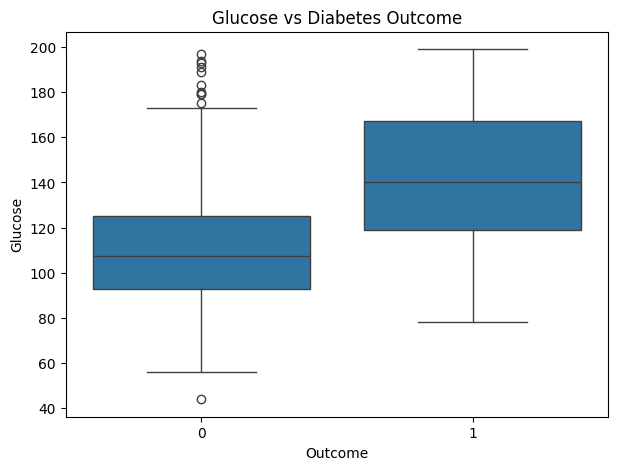

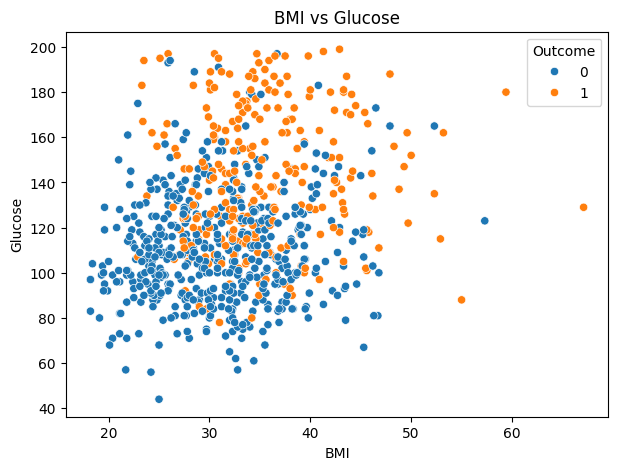


Accuracy Score:
0.7792207792207793

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


Confusion Matrix:
[[88 12]
 [22 32]]

Feature Importance:
                    Feature  Importance
1                   Glucose    0.274086
5                       BMI    0.161903
6  DiabetesPedigreeFunction    0.125020
7                       Age    0.112985
4                   Insulin    0.091224
2             BloodPressure    0.083518
0               Pregnancies    0.080795
3             SkinThickness    0.070468


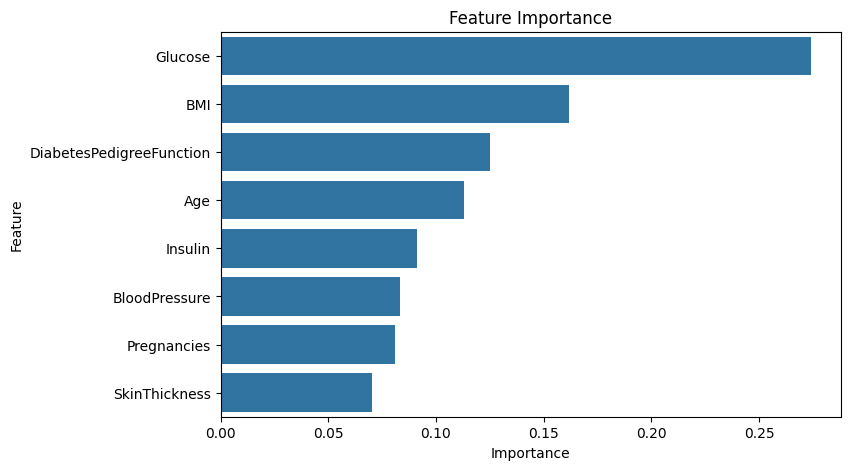


========== Medical Insights ==========
1. High glucose levels are strongly associated with diabetes.
2. BMI is an important risk factor.
3. Older patients have a higher likelihood of diabetes.
4. Random Forest identifies Glucose, BMI, and Age as the most important features.
5. The model can support early diabetes risk prediction.


In [3]:
# ==========================================
# Data Mining Project 7: Healthcare Data Analysis
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv("diabetes_data/diabetes.csv")

# Display first 5 rows
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nSummary Statistics:")
print(df.describe())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# ------------------------------------------
# Data Preprocessing
# Replace impossible zero values with NaN
# ------------------------------------------
columns = ['Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI']

df[columns] = df[columns].replace(0, np.nan)

# Fill missing values with median
imputer = SimpleImputer(strategy='median')
df[columns] = imputer.fit_transform(df[columns])

# ------------------------------------------
# Exploratory Data Analysis (EDA)
# ------------------------------------------

# Diabetes Outcome Count
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# BMI Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

# Glucose Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Glucose'], bins=20, kde=True)
plt.title("Glucose Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

# Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df)
plt.title("BMI vs Glucose")
plt.show()

# ------------------------------------------
# Feature Selection
# ------------------------------------------
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# ------------------------------------------
# Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# Model Training
# ------------------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------
# Prediction
# ------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------
# Model Evaluation
# ------------------------------------------
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------
# Feature Importance
# ------------------------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

# ------------------------------------------
# Medical Insights Report
# ------------------------------------------
print("\n========== Medical Insights ==========")
print("1. High glucose levels are strongly associated with diabetes.")
print("2. BMI is an important risk factor.")
print("3. Older patients have a higher likelihood of diabetes.")
print("4. Random Forest identifies Glucose, BMI, and Age as the most important features.")
print("5. The model can support early diabetes risk prediction.")

In [2]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/archive (14).zip'
extract_dir = 'diabetes_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

# List contents of the extracted directory to confirm the CSV file name and path
print("Contents of extracted directory:")
print(os.listdir(extract_dir))

'/content/archive (14).zip' unzipped to 'diabetes_data'
Contents of extracted directory:
['diabetes.csv']
